# **HR Attrition Analysis**
---


# **1. LIBRARIES SETUP & ENVIRONMENT**


In [24]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
os.makedirs('outputs', exist_ok=True)


In [25]:

def savefig_and_show(filename):
    plt.savefig(f'outputs/{filename}.png', bbox_inches='tight', dpi=130, transparent=True)
    plt.show()
    plt.clf()


---


# **2. LOAD DATA**


In [26]:
df = pd.read_csv('hr_attrition_cleaned_data.csv')


In [27]:
df.columns = df.columns.str.strip().str.lower()
print("Data shape:", df.shape)
print("Sample columns:", df.columns[:8].tolist())
display(df.head(3))


Data shape: (1470, 32)
Sample columns: ['age', 'attrition', 'businesstravel', 'dailyrate', 'department', 'distancefromhome', 'education', 'educationfield']


,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeenumber,environmentsatisfaction,...,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0


---


# **3. DATA QUALITY CHECKS & VISUALIZATION**


In [28]:
print("\nMissing Values Per Column:")
print(pd.DataFrame(df.isnull().sum(), columns=['Missing Count']))



Missing Values Per Column:
                          Missing Count
age                                   0
attrition                             0
businesstravel                        0
dailyrate                             0
department                            0
distancefromhome                      0
education                             0
educationfield                        0
employeenumber                        0
environmentsatisfaction               0
gender                                0
hourlyrate                            0
jobinvolvement                        0
joblevel                              0
jobrole                               0
jobsatisfaction                       0
maritalstatus                         0
monthlyincome                         0
monthlyrate                           0
numcompaniesworked                    0
overtime                              0
percentsalaryhike                     0
performancerating                     0
relationship

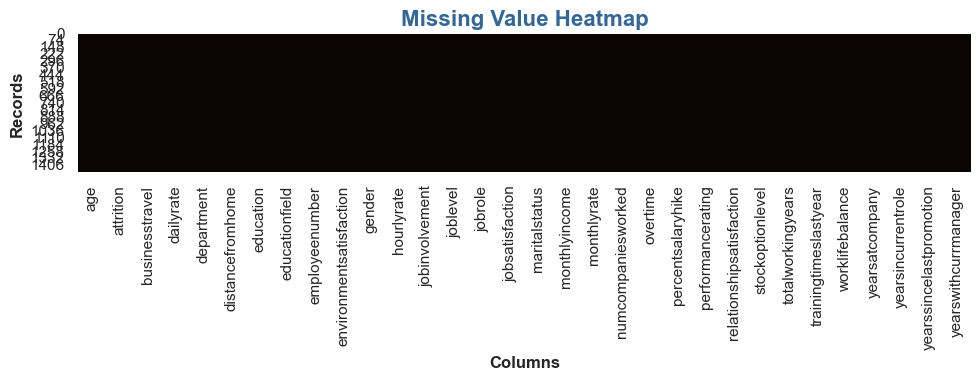

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='mako')
plt.title('Missing Value Heatmap', color='#326798', fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Records')
plt.tight_layout()
savefig_and_show('missing_value_heatmap')


In [30]:

print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [31]:
df = df.drop_duplicates()


---


# **4. DATA CLEANING**


In [32]:
drop_cols = [c for c in ["employeecount", "employeenumber", "over18", "standardhours"] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)


In [33]:
for col in df.select_dtypes('number').columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes('object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


---


# **5. TARGET DISTRIBUTION (ATTRITION)**


In [34]:
print("\nAttrition Value Counts:\n", df['attrition'].value_counts())
print("\nAttrition Crosstab:\n", pd.crosstab(df['attrition'], columns='Count'))
attr_perc = df['attrition'].value_counts(normalize=True) * 100



Attrition Value Counts:
 attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Crosstab:
 col_0      Count
attrition       
No          1233
Yes          237


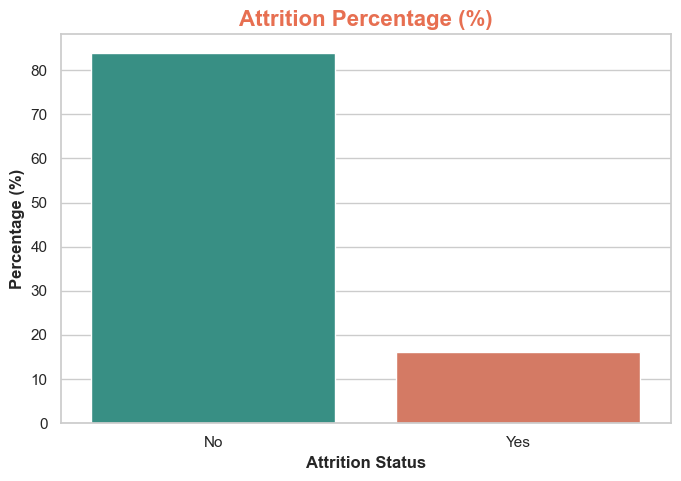

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(7,5))
sns.barplot(x=attr_perc.index, y=attr_perc.values, palette=['#2a9d8f', '#e76f51'])
plt.title("Attrition Percentage (%)", color='#e76f51', fontweight="bold")
plt.xlabel("Attrition Status")
plt.ylabel("Percentage (%)")
plt.tight_layout()
savefig_and_show('attrition_percentage_bar')



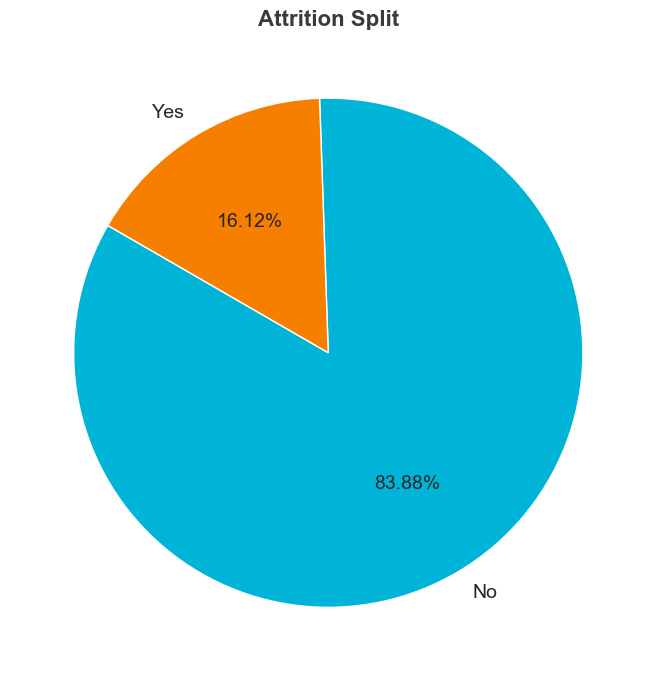

<Figure size 640x480 with 0 Axes>

In [36]:

plt.figure(figsize=(7,7))
plt.pie(attr_perc, labels=attr_perc.index, autopct='%1.2f%%',
        colors=['#00b4d8', '#f77f00'], startangle=150, textprops={'fontsize':14})
plt.title("Attrition Split", color='#3a3a3a', fontweight='bold')
plt.tight_layout()
savefig_and_show('attrition_pie')
display()


---


# **6. EXPLORATORY DATA ANALYSIS (EDA)**



Crosstab of age Quartiles by Attrition:
age        (17.999, 30.0]  (30.0, 36.0]  (36.0, 43.0]  (43.0, 60.0]
attrition                                                          
No                    286           346           296           305
Yes                   100            66            29            42


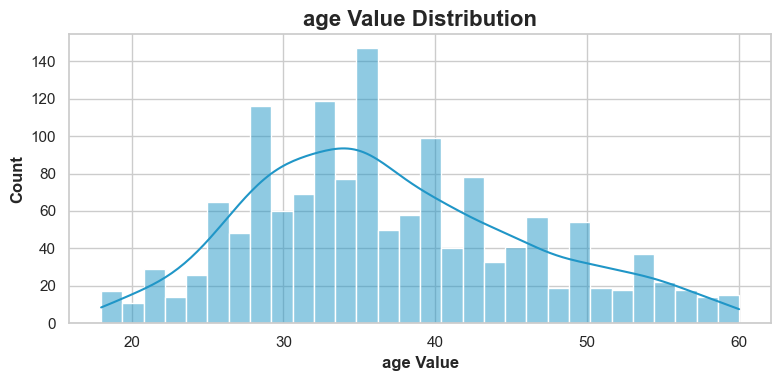


Crosstab of dailyrate Quartiles by Attrition:
dailyrate  (101.999, 465.0]  (465.0, 802.0]  (802.0, 1157.0]  (1157.0, 1499.0]
attrition                                                                     
No                      295             308              311               319
Yes                      74              59               56                48


<Figure size 640x480 with 0 Axes>

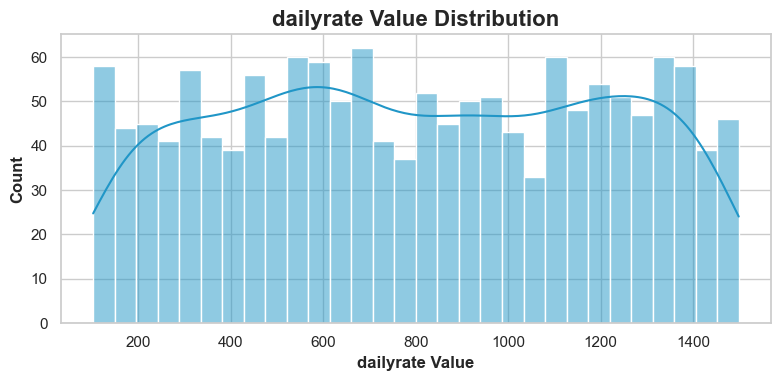


Crosstab of distancefromhome Quartiles by Attrition:
distancefromhome  (0.999, 2.0]  (2.0, 7.0]  (7.0, 14.0]  (14.0, 29.0]
attrition                                                            
No                         365         305          281           282
Yes                         54          51           59            73


<Figure size 640x480 with 0 Axes>

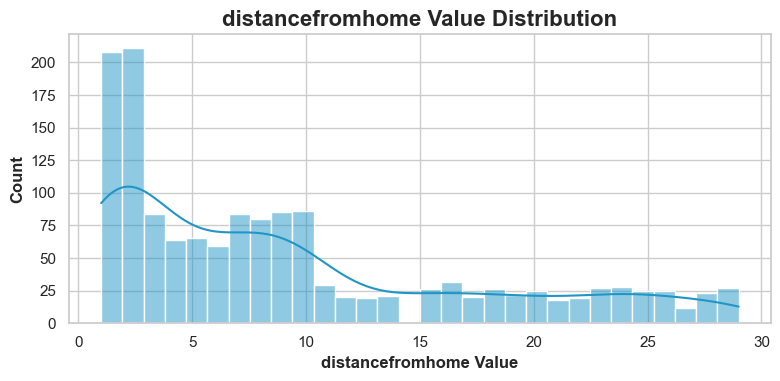


Crosstab of education Quartiles by Attrition:
education  (0.999, 2.0]  (2.0, 3.0]  (3.0, 4.0]  (4.0, 5.0]
attrition                                                  
No                  377         473         340          43
Yes                  75          99          58           5


<Figure size 640x480 with 0 Axes>

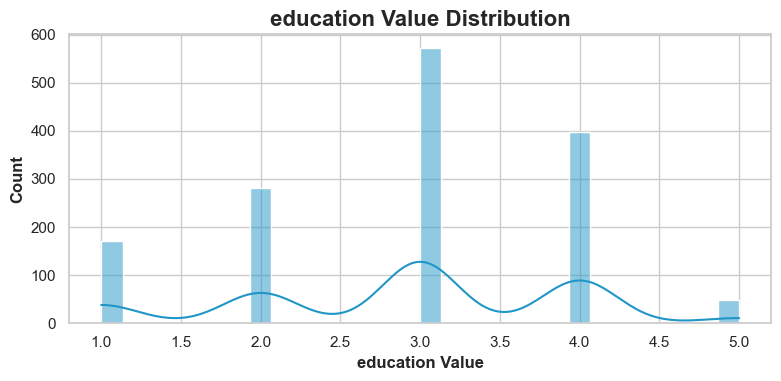


Crosstab of environmentsatisfaction Quartiles by Attrition:
environmentsatisfaction  (0.999, 2.0]  (2.0, 3.0]  (3.0, 4.0]
attrition                                                    
No                                456         391         386
Yes                               115          62          60


<Figure size 640x480 with 0 Axes>

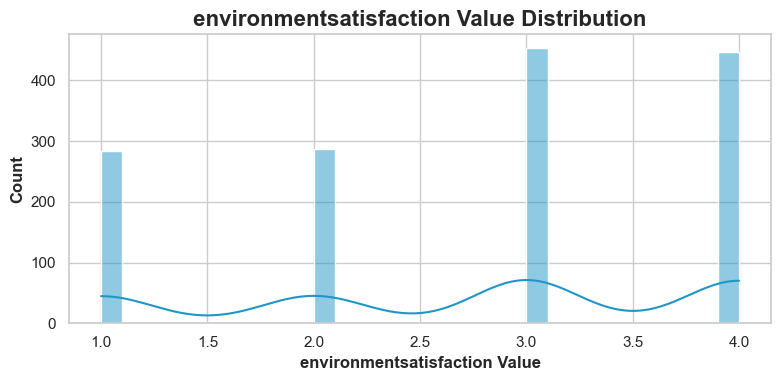


Crosstab of hourlyrate Quartiles by Attrition:
hourlyrate  (29.999, 48.0]  (48.0, 66.0]  (66.0, 83.75]  (83.75, 100.0]
attrition                                                              
No                     318           310            298             307
Yes                     57            68             51              61


<Figure size 640x480 with 0 Axes>

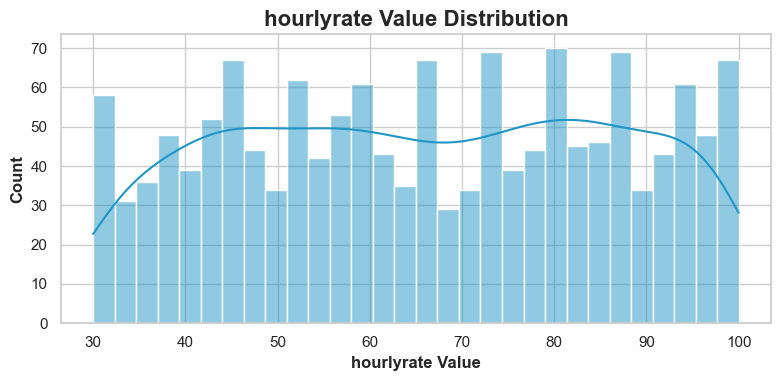


Crosstab of jobinvolvement Quartiles by Attrition:
jobinvolvement  (0.999, 2.0]  (2.0, 3.0]  (3.0, 4.0]
attrition                                           
No                       359         743         131
Yes                       99         125          13


<Figure size 640x480 with 0 Axes>

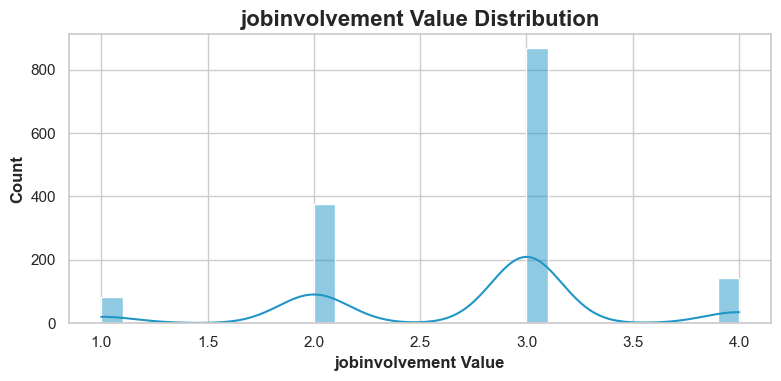


Crosstab of joblevel Quartiles by Attrition:
joblevel   (0.999, 2.0]  (2.0, 3.0]  (3.0, 5.0]
attrition                                      
No                  882         186         165
Yes                 195          32          10


<Figure size 640x480 with 0 Axes>

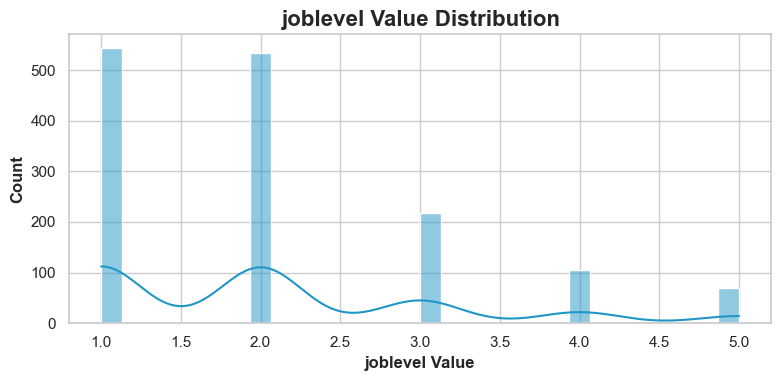


Crosstab of jobsatisfaction Quartiles by Attrition:
jobsatisfaction  (0.999, 2.0]  (2.0, 3.0]  (3.0, 4.0]
attrition                                            
No                        457         369         407
Yes                       112          73          52


<Figure size 640x480 with 0 Axes>

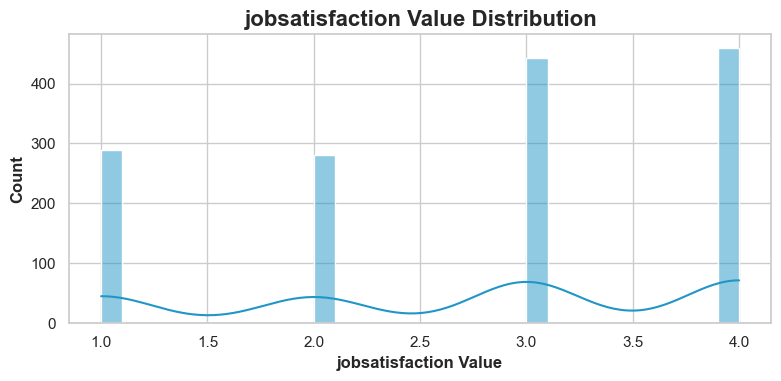


Crosstab of monthlyincome Quartiles by Attrition:
monthlyincome  (1008.999, 2911.0]  (2911.0, 4919.0]  (4919.0, 8379.0]  \
attrition                                                               
No                            261               314               328   
Yes                           108                52                39   

monthlyincome  (8379.0, 19999.0]  
attrition                         
No                           330  
Yes                           38  


<Figure size 640x480 with 0 Axes>

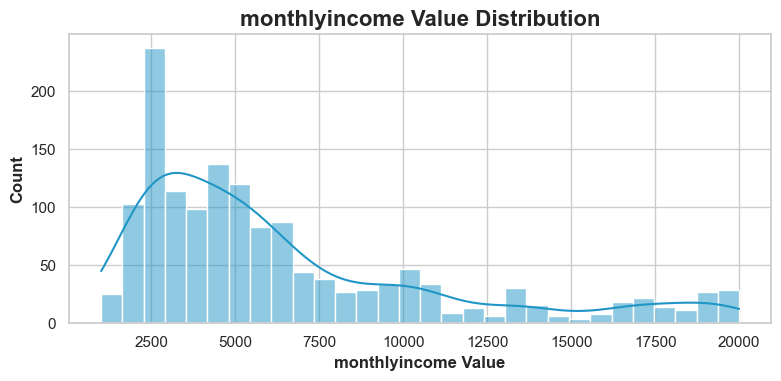


Crosstab of monthlyrate Quartiles by Attrition:
monthlyrate  (2093.999, 8047.0]  (8047.0, 14235.5]  (14235.5, 20461.5]  \
attrition                                                                
No                          315                306                 310   
Yes                          53                 61                  57   

monthlyrate  (20461.5, 26999.0]  
attrition                        
No                          302  
Yes                          66  


<Figure size 640x480 with 0 Axes>

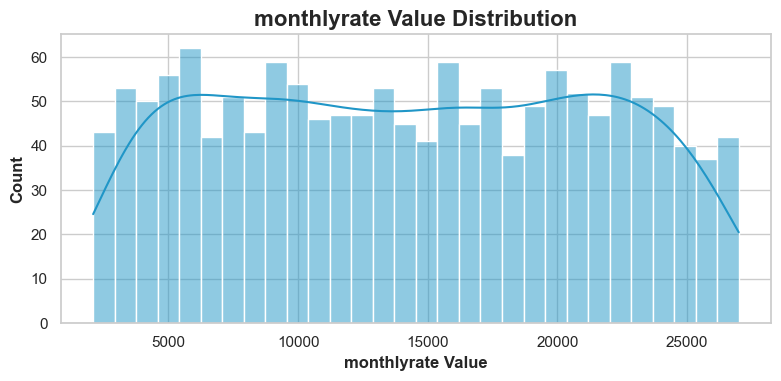


Crosstab of numcompaniesworked Quartiles by Attrition:
numcompaniesworked  (-0.001, 1.0]  (1.0, 2.0]  (2.0, 4.0]  (4.0, 9.0]
attrition                                                            
No                            597         130         265         241
Yes                           121          16          33          67


<Figure size 640x480 with 0 Axes>

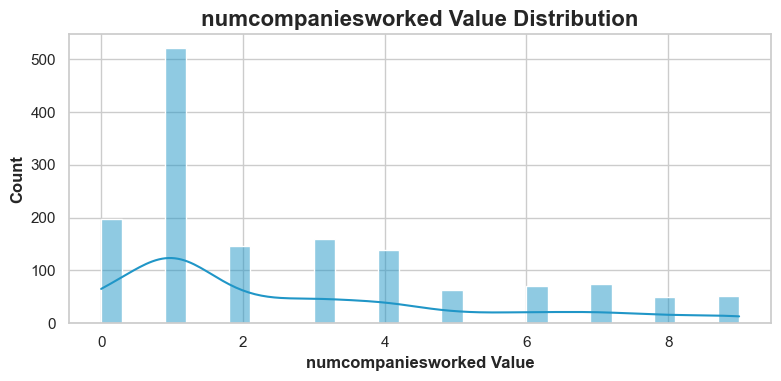


Crosstab of percentsalaryhike Quartiles by Attrition:
percentsalaryhike  (10.999, 12.0]  (12.0, 14.0]  (14.0, 18.0]  (18.0, 25.0]
attrition                                                                  
No                            334           352           291           256
Yes                            74            58            59            46


<Figure size 640x480 with 0 Axes>

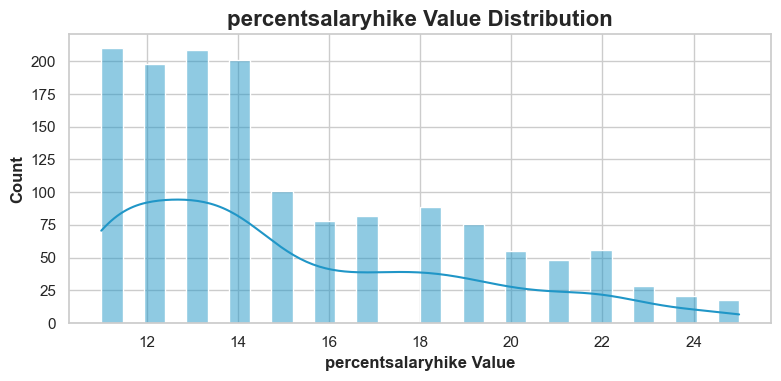


Crosstab of performancerating Quartiles by Attrition:
performancerating  (2.999, 4.0]
attrition                      
No                         1233
Yes                         237


<Figure size 640x480 with 0 Axes>

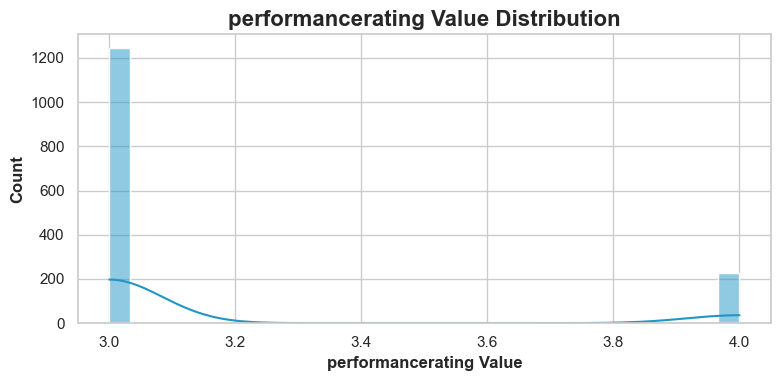


Crosstab of relationshipsatisfaction Quartiles by Attrition:
relationshipsatisfaction  (0.999, 2.0]  (2.0, 3.0]  (3.0, 4.0]
attrition                                                     
No                                 477         388         368
Yes                                102          71          64


<Figure size 640x480 with 0 Axes>

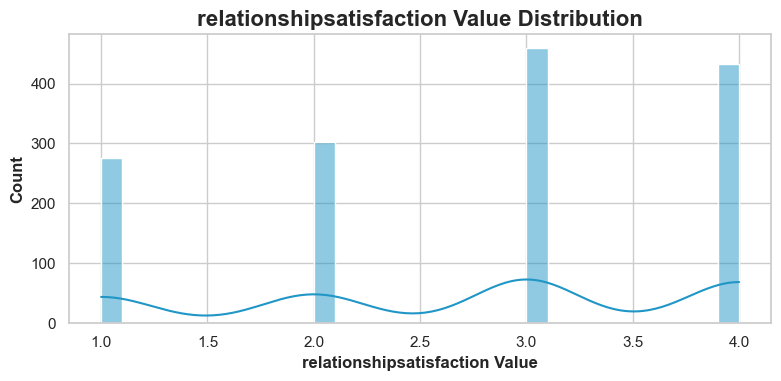


Crosstab of stockoptionlevel Quartiles by Attrition:
stockoptionlevel  (-0.001, 1.0]  (1.0, 3.0]
attrition                                  
No                         1017         216
Yes                         210          27


<Figure size 640x480 with 0 Axes>

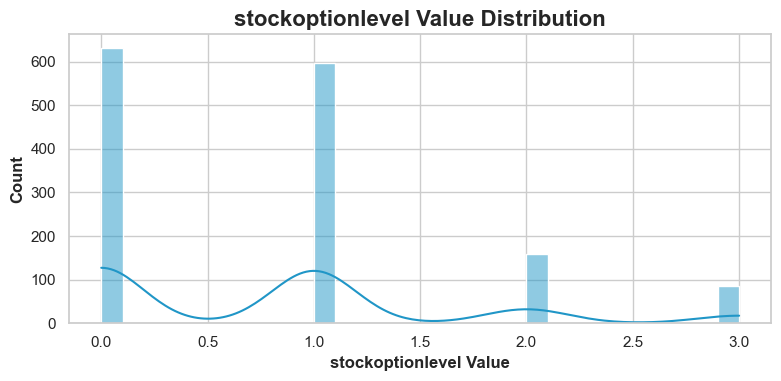


Crosstab of totalworkingyears Quartiles by Attrition:
totalworkingyears  (-0.001, 6.0]  (6.0, 10.0]  (10.0, 15.0]  (15.0, 40.0]
attrition                                                                
No                           328          413           167           325
Yes                          113           69            24            31


<Figure size 640x480 with 0 Axes>

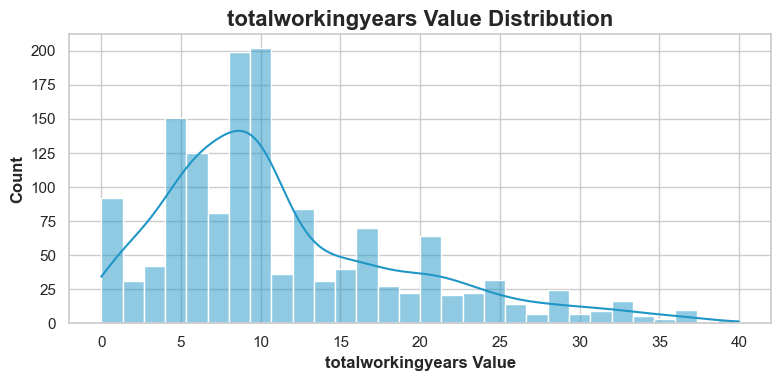


Crosstab of trainingtimeslastyear Quartiles by Attrition:
trainingtimeslastyear  (-0.001, 2.0]  (2.0, 3.0]  (3.0, 6.0]
attrition                                                   
No                               550         422         261
Yes                              122          69          46


<Figure size 640x480 with 0 Axes>

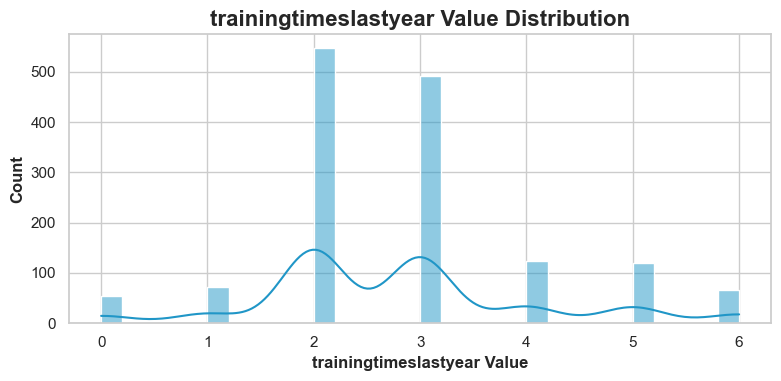


Crosstab of worklifebalance Quartiles by Attrition:
worklifebalance  (0.999, 2.0]  (2.0, 3.0]  (3.0, 4.0]
attrition                                            
No                        341         766         126
Yes                        83         127          27


<Figure size 640x480 with 0 Axes>

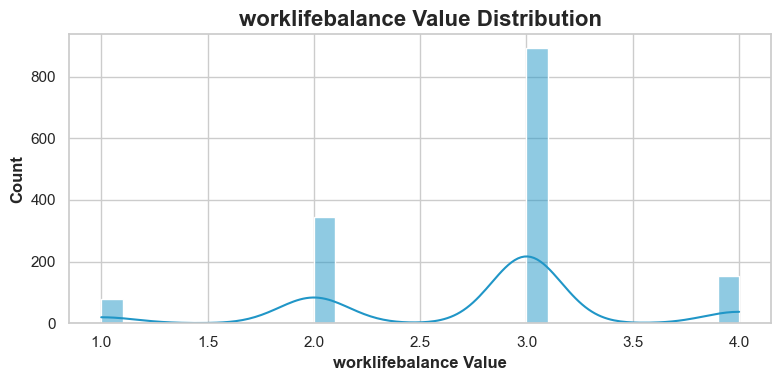


Crosstab of yearsatcompany Quartiles by Attrition:
yearsatcompany  (-0.001, 3.0]  (3.0, 5.0]  (5.0, 9.0]  (9.0, 40.0]
attrition                                                         
No                        348         266         291          328
Yes                       122          40          37           38


<Figure size 640x480 with 0 Axes>

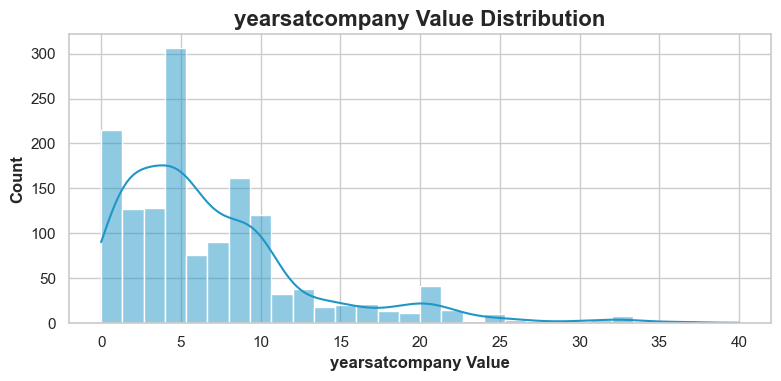


Crosstab of yearsincurrentrole Quartiles by Attrition:
yearsincurrentrole  (-0.001, 2.0]  (2.0, 3.0]  (3.0, 7.0]  (7.0, 18.0]
attrition                                                             
No                            521         119         350          243
Yes                           152          16          49           20


<Figure size 640x480 with 0 Axes>

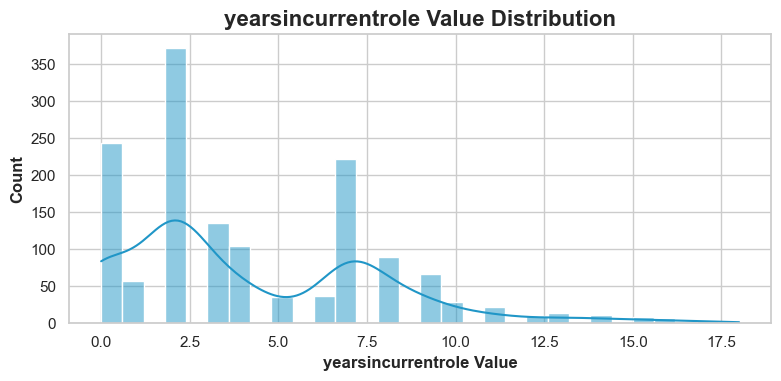


Crosstab of yearssincelastpromotion Quartiles by Attrition:
yearssincelastpromotion  (-0.001, 1.0]  (1.0, 3.0]  (3.0, 15.0]
attrition                                                      
No                                 779         175          279
Yes                                159          36           42


<Figure size 640x480 with 0 Axes>

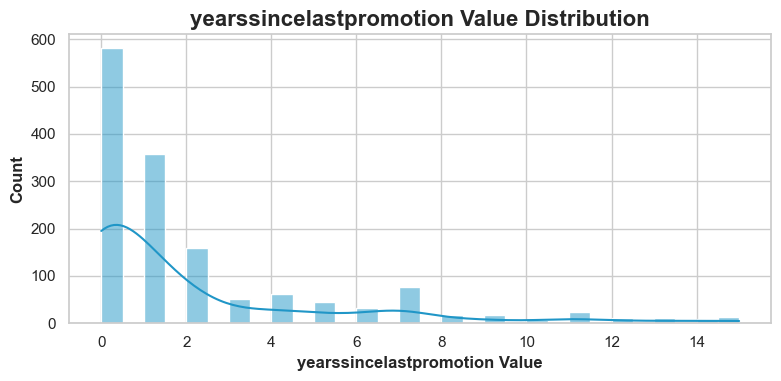


Crosstab of yearswithcurrmanager Quartiles by Attrition:
yearswithcurrmanager  (-0.001, 2.0]  (2.0, 3.0]  (3.0, 7.0]  (7.0, 17.0]
attrition                                                               
No                              537         123         324          249
Yes                             146          19          50           22


<Figure size 640x480 with 0 Axes>

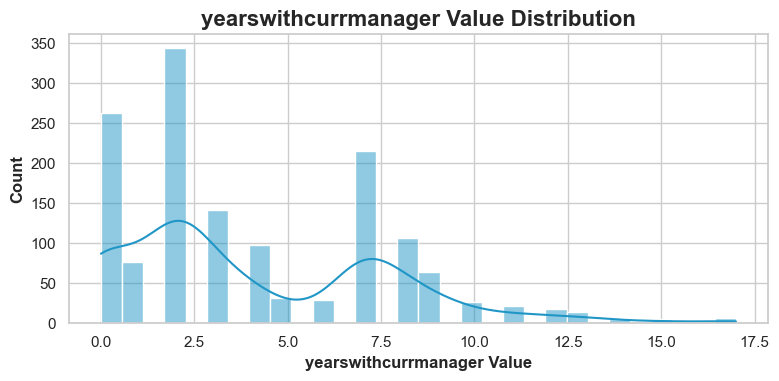

<Figure size 640x480 with 0 Axes>

In [37]:

# ---- Numeric Features ----
for col in df.select_dtypes('number').columns:
    if col == 'attrition': continue
    print(f"\nCrosstab of {col} Quartiles by Attrition:")
    qcut_col = pd.qcut(df[col], q=4, duplicates='drop')
    print(pd.crosstab(df['attrition'], qcut_col))
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True, color='#2096c7')
    plt.title(f"{col} Value Distribution", fontweight='bold')
    plt.xlabel(f"{col} Value")
    plt.ylabel("Count")
    plt.tight_layout()
    savefig_and_show(f"{col}_hist")




Crosstab of attrition by Attrition:
attrition    No  Yes
attrition           
No         1233    0
Yes           0  237


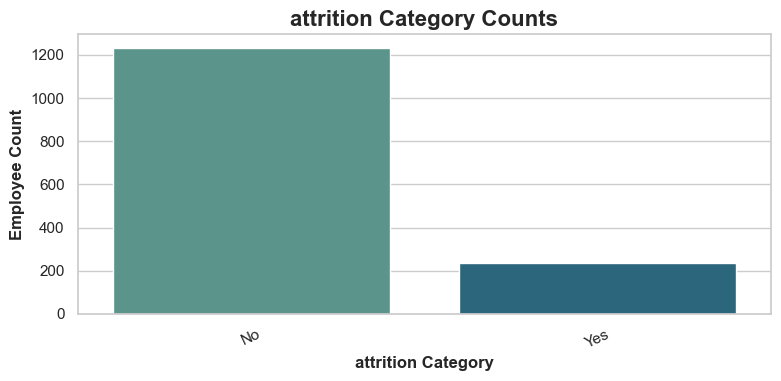


Crosstab of businesstravel by Attrition:
attrition           No  Yes
businesstravel             
Non-Travel         138   12
Travel_Frequently  208   69
Travel_Rarely      887  156


<Figure size 640x480 with 0 Axes>

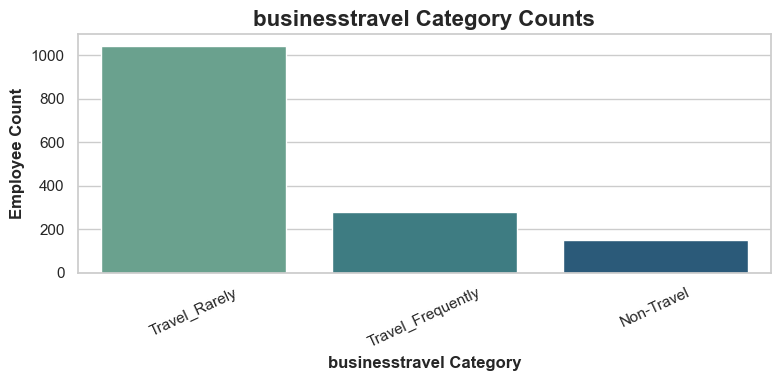


Crosstab of department by Attrition:
attrition                No  Yes
department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


<Figure size 640x480 with 0 Axes>

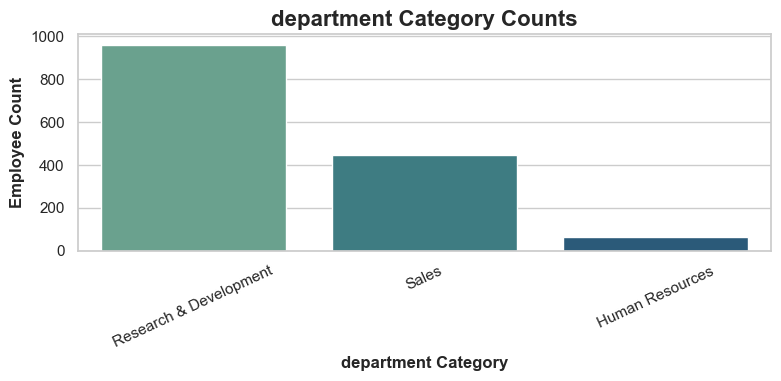


Crosstab of educationfield by Attrition:
attrition          No  Yes
educationfield            
Human Resources    20    7
Life Sciences     517   89
Marketing         124   35
Medical           401   63
Other              71   11
Technical Degree  100   32


<Figure size 640x480 with 0 Axes>

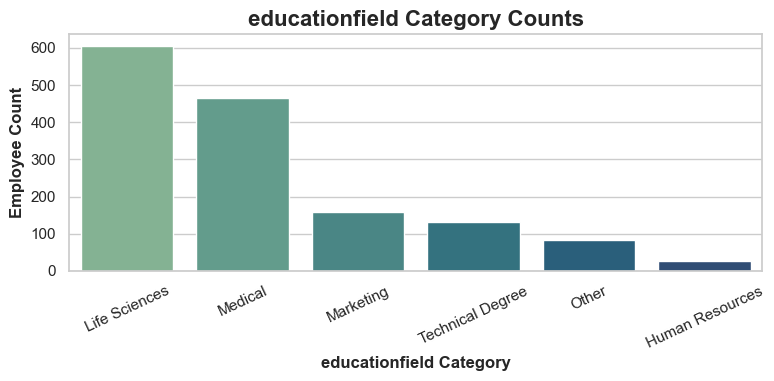


Crosstab of gender by Attrition:
attrition   No  Yes
gender             
Female     501   87
Male       732  150


<Figure size 640x480 with 0 Axes>

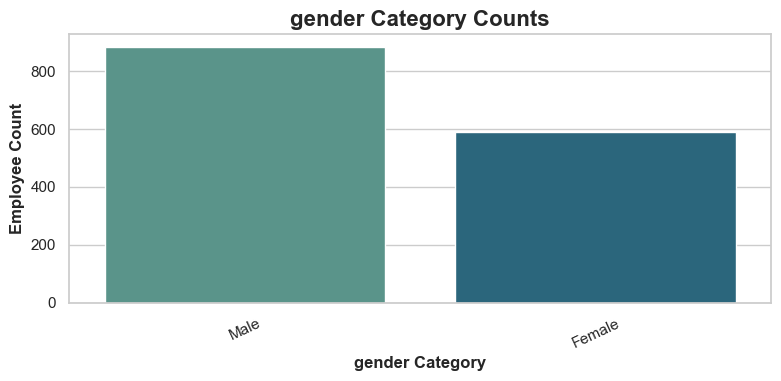


Crosstab of jobrole by Attrition:
attrition                   No  Yes
jobrole                            
Healthcare Representative  122    9
Human Resources             40   12
Laboratory Technician      197   62
Manager                     97    5
Manufacturing Director     135   10
Research Director           78    2
Research Scientist         245   47
Sales Executive            269   57
Sales Representative        50   33


<Figure size 640x480 with 0 Axes>

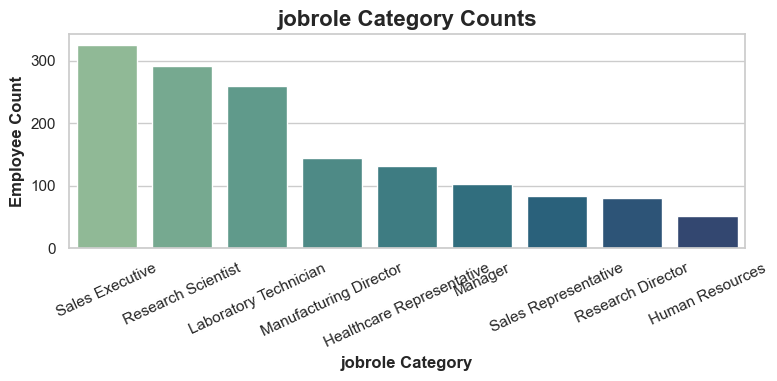


Crosstab of maritalstatus by Attrition:
attrition       No  Yes
maritalstatus          
Divorced       294   33
Married        589   84
Single         350  120


<Figure size 640x480 with 0 Axes>

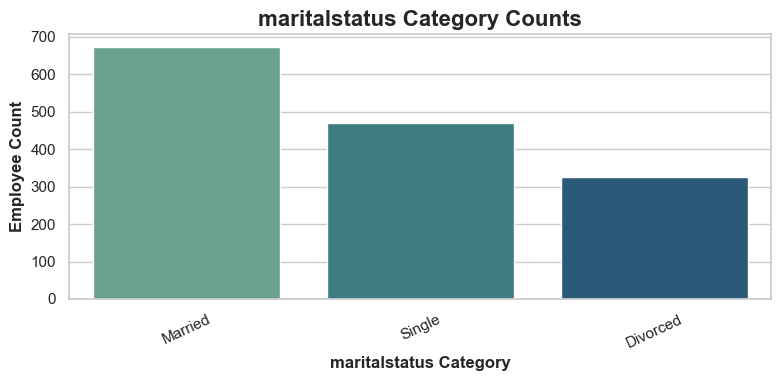


Crosstab of overtime by Attrition:
attrition   No  Yes
overtime           
No         944  110
Yes        289  127


<Figure size 640x480 with 0 Axes>

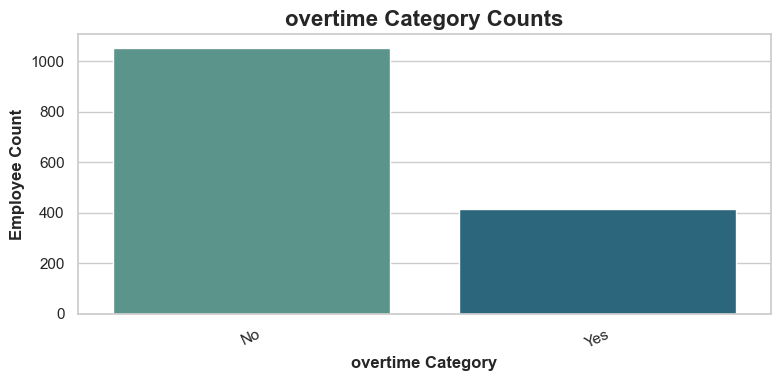

<Figure size 640x480 with 0 Axes>

In [38]:

# ---- Categorical Features ----
for col in df.select_dtypes('object').columns:
    if df[col].nunique() > 25: continue
    print(f"\nCrosstab of {col} by Attrition:")
    print(pd.crosstab(df[col], df['attrition']))
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='crest')
    plt.title(f"{col} Category Counts", fontweight='bold')
    plt.xlabel(f"{col} Category")
    plt.ylabel("Employee Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    savefig_and_show(f"{col}_countplot")



Pivot Summary for age by Attrition:
                mean median min max
                 age    age age age
attrition                          
No         37.561233   36.0  18  60
Yes        33.607595   32.0  18  58


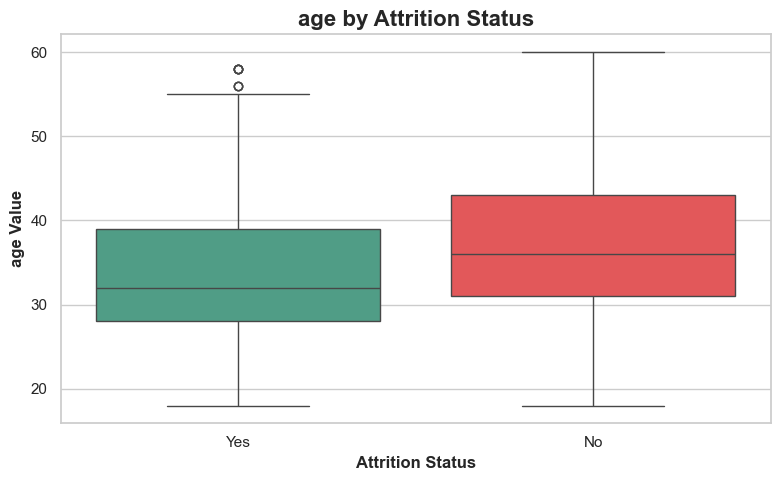


Pivot Summary for dailyrate by Attrition:
                 mean    median       min       max
            dailyrate dailyrate dailyrate dailyrate
attrition                                          
No         812.504461     817.0       102      1499
Yes        750.362869     699.0       103      1496


<Figure size 640x480 with 0 Axes>

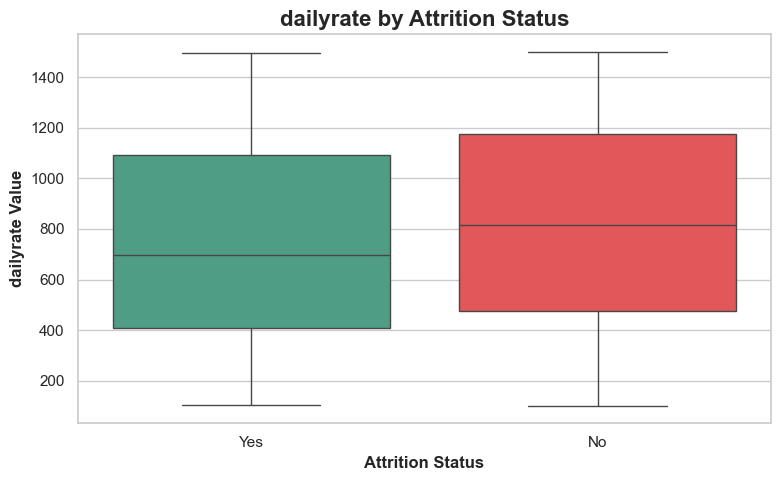


Pivot Summary for distancefromhome by Attrition:
                      mean           median              min              max
          distancefromhome distancefromhome distancefromhome distancefromhome
attrition                                                                    
No                8.915653              7.0                1               29
Yes              10.632911              9.0                1               29


<Figure size 640x480 with 0 Axes>

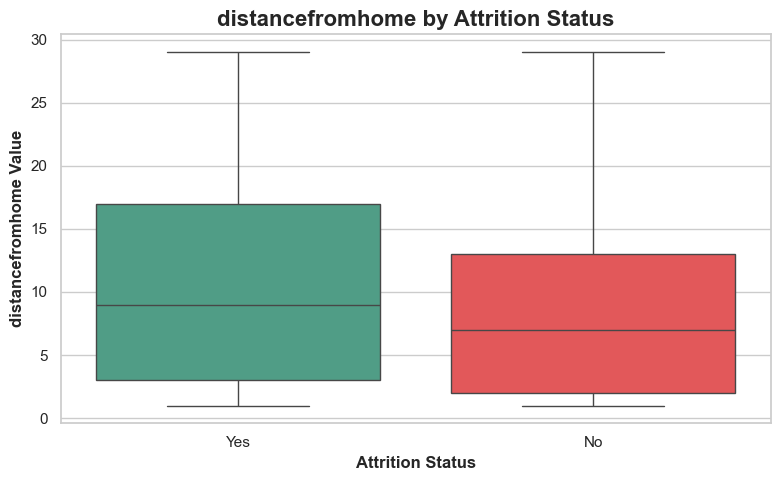


Pivot Summary for education by Attrition:
               mean    median       min       max
          education education education education
attrition                                        
No         2.927007       3.0         1         5
Yes        2.839662       3.0         1         5


<Figure size 640x480 with 0 Axes>

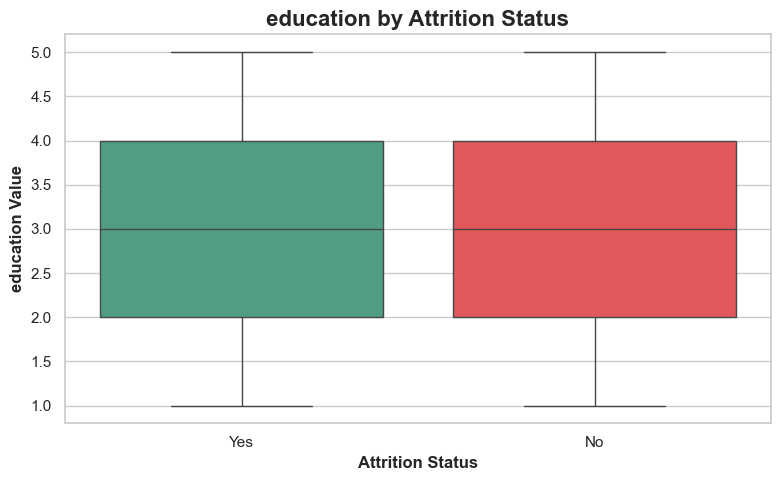


Pivot Summary for environmentsatisfaction by Attrition:
                             mean                  median  \
          environmentsatisfaction environmentsatisfaction   
attrition                                                   
No                       2.771290                     3.0   
Yes                      2.464135                     3.0   

                              min                     max  
          environmentsatisfaction environmentsatisfaction  
attrition                                                  
No                              1                       4  
Yes                             1                       4  


<Figure size 640x480 with 0 Axes>

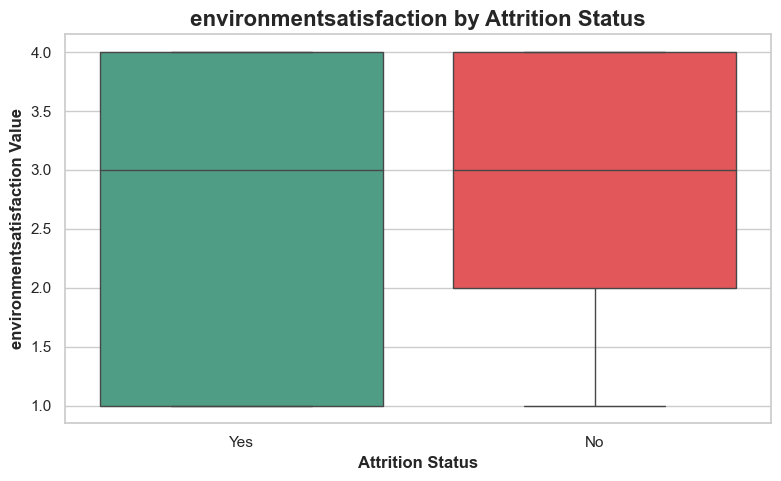


Pivot Summary for hourlyrate by Attrition:
                mean     median        min        max
          hourlyrate hourlyrate hourlyrate hourlyrate
attrition                                            
No         65.952149       66.0         30        100
Yes        65.573840       66.0         31        100


<Figure size 640x480 with 0 Axes>

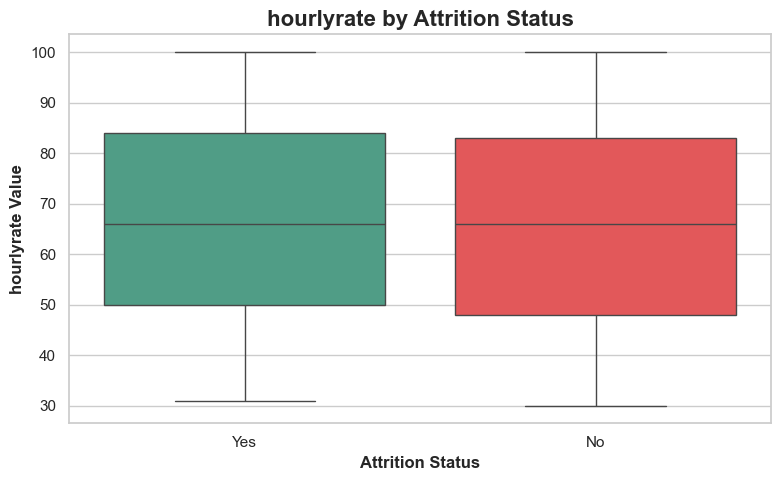


Pivot Summary for jobinvolvement by Attrition:
                    mean         median            min            max
          jobinvolvement jobinvolvement jobinvolvement jobinvolvement
attrition                                                            
No              2.770479            3.0              1              4
Yes             2.518987            3.0              1              4


<Figure size 640x480 with 0 Axes>

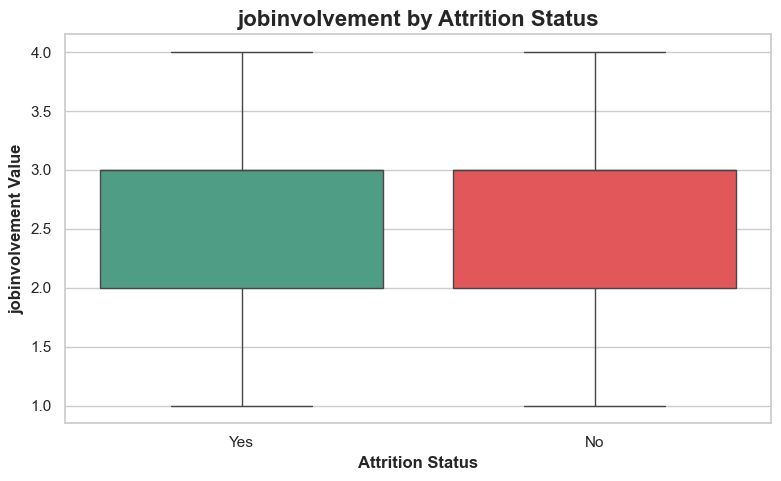


Pivot Summary for joblevel by Attrition:
               mean   median      min      max
           joblevel joblevel joblevel joblevel
attrition                                     
No         2.145985      2.0        1        5
Yes        1.637131      1.0        1        5


<Figure size 640x480 with 0 Axes>

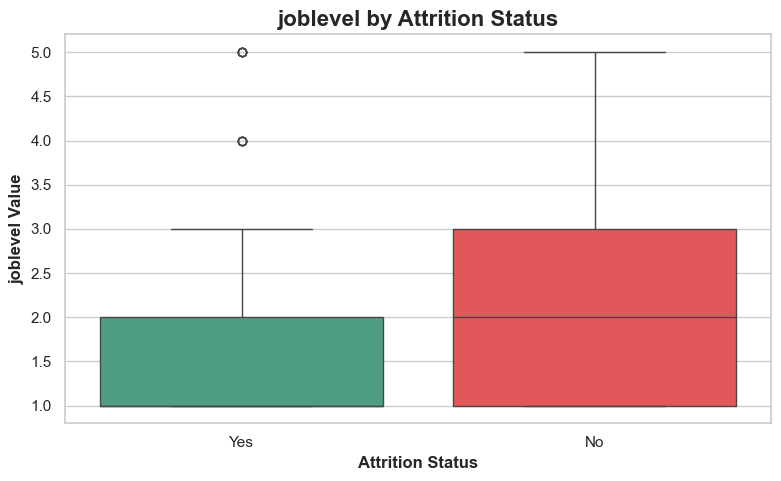


Pivot Summary for jobsatisfaction by Attrition:
                     mean          median             min             max
          jobsatisfaction jobsatisfaction jobsatisfaction jobsatisfaction
attrition                                                                
No               2.778589             3.0               1               4
Yes              2.468354             3.0               1               4


<Figure size 640x480 with 0 Axes>

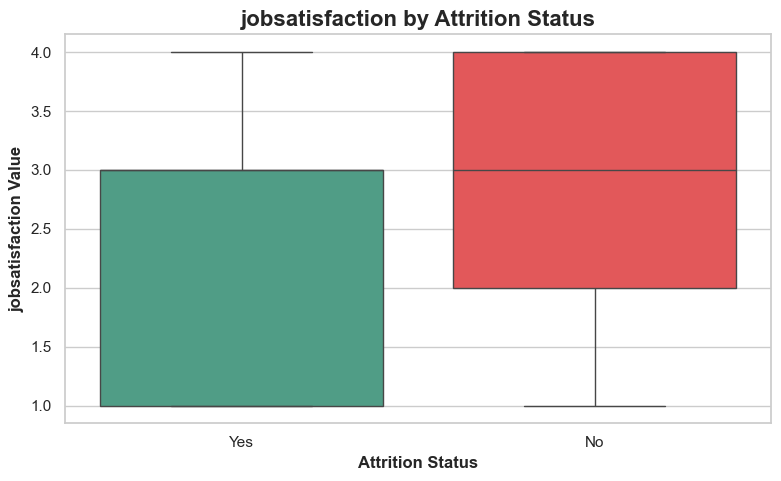


Pivot Summary for monthlyincome by Attrition:
                   mean        median           min           max
          monthlyincome monthlyincome monthlyincome monthlyincome
attrition                                                        
No          6832.739659        5204.0          1051         19999
Yes         4787.092827        3202.0          1009         19859


<Figure size 640x480 with 0 Axes>

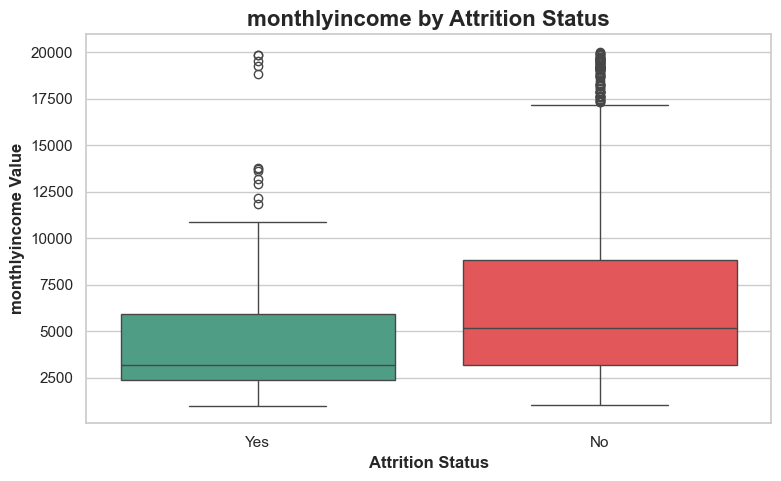


Pivot Summary for monthlyrate by Attrition:
                   mean      median         min         max
            monthlyrate monthlyrate monthlyrate monthlyrate
attrition                                                  
No         14265.779400     14120.0        2094       26997
Yes        14559.308017     14618.0        2326       26999


<Figure size 640x480 with 0 Axes>

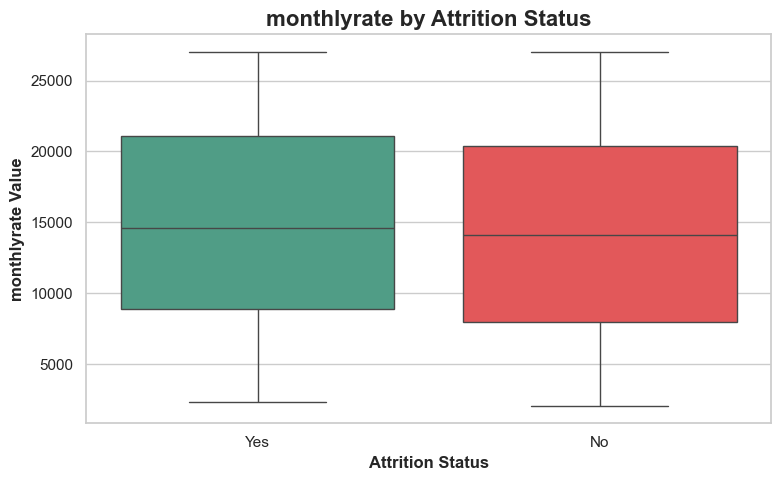


Pivot Summary for numcompaniesworked by Attrition:
                        mean             median                min  \
          numcompaniesworked numcompaniesworked numcompaniesworked   
attrition                                                            
No                  2.645580                2.0                  0   
Yes                 2.940928                1.0                  0   

                         max  
          numcompaniesworked  
attrition                     
No                         9  
Yes                        9  


<Figure size 640x480 with 0 Axes>

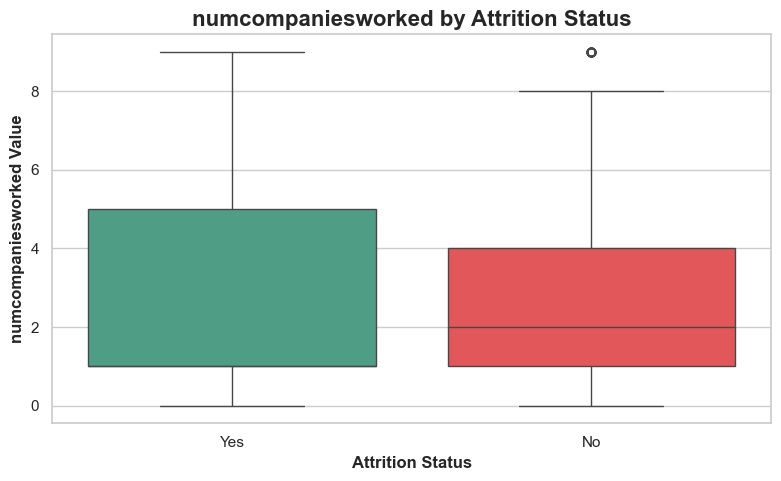


Pivot Summary for percentsalaryhike by Attrition:
                       mean            median               min  \
          percentsalaryhike percentsalaryhike percentsalaryhike   
attrition                                                         
No                15.231144              14.0                11   
Yes               15.097046              14.0                11   

                        max  
          percentsalaryhike  
attrition                    
No                       25  
Yes                      25  


<Figure size 640x480 with 0 Axes>

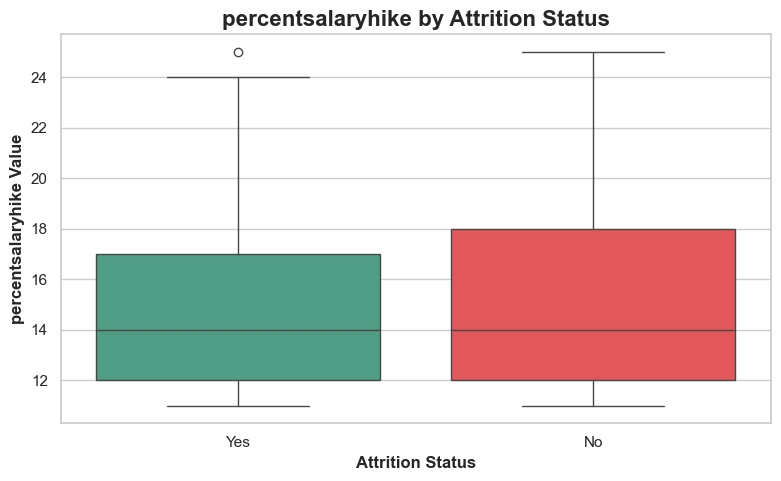


Pivot Summary for performancerating by Attrition:
                       mean            median               min  \
          performancerating performancerating performancerating   
attrition                                                         
No                 3.153285               3.0                 3   
Yes                3.156118               3.0                 3   

                        max  
          performancerating  
attrition                    
No                        4  
Yes                       4  


<Figure size 640x480 with 0 Axes>

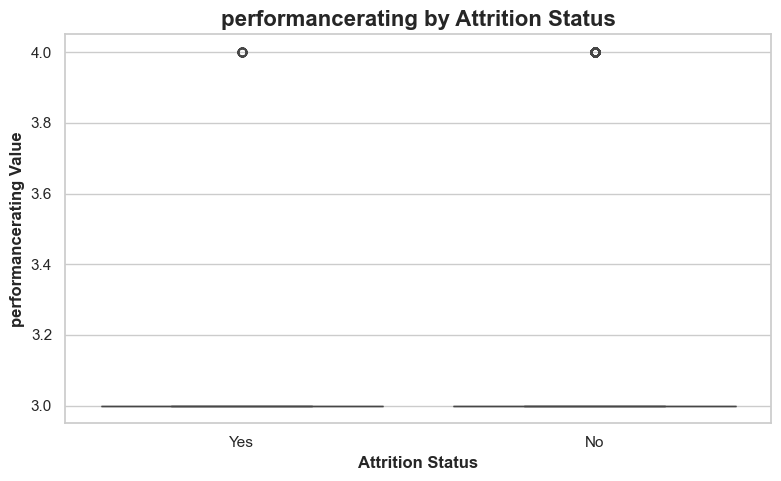


Pivot Summary for relationshipsatisfaction by Attrition:
                              mean                   median  \
          relationshipsatisfaction relationshipsatisfaction   
attrition                                                     
No                        2.733982                      3.0   
Yes                       2.599156                      3.0   

                               min                      max  
          relationshipsatisfaction relationshipsatisfaction  
attrition                                                    
No                               1                        4  
Yes                              1                        4  


<Figure size 640x480 with 0 Axes>

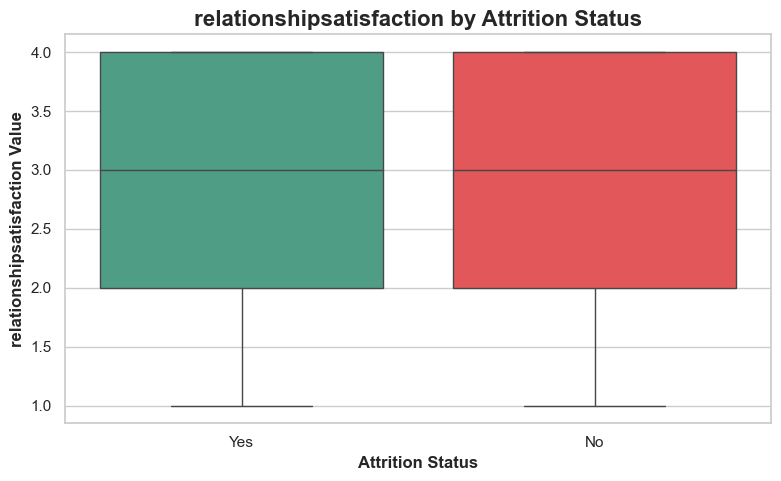


Pivot Summary for stockoptionlevel by Attrition:
                      mean           median              min              max
          stockoptionlevel stockoptionlevel stockoptionlevel stockoptionlevel
attrition                                                                    
No                0.845093              1.0                0                3
Yes               0.527426              0.0                0                3


<Figure size 640x480 with 0 Axes>

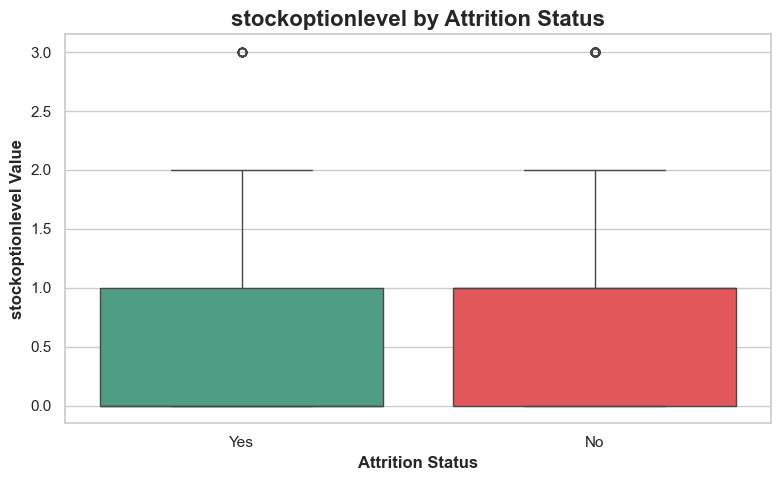


Pivot Summary for totalworkingyears by Attrition:
                       mean            median               min  \
          totalworkingyears totalworkingyears totalworkingyears   
attrition                                                         
No                11.862936              10.0                 0   
Yes                8.244726               7.0                 0   

                        max  
          totalworkingyears  
attrition                    
No                       38  
Yes                      40  


<Figure size 640x480 with 0 Axes>

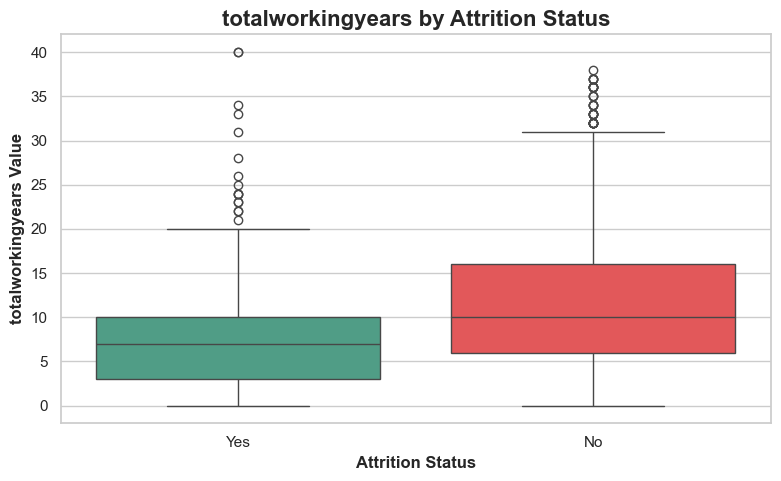


Pivot Summary for trainingtimeslastyear by Attrition:
                           mean                median                   min  \
          trainingtimeslastyear trainingtimeslastyear trainingtimeslastyear   
attrition                                                                     
No                     2.832928                   3.0                     0   
Yes                    2.624473                   2.0                     0   

                            max  
          trainingtimeslastyear  
attrition                        
No                            6  
Yes                           6  


<Figure size 640x480 with 0 Axes>

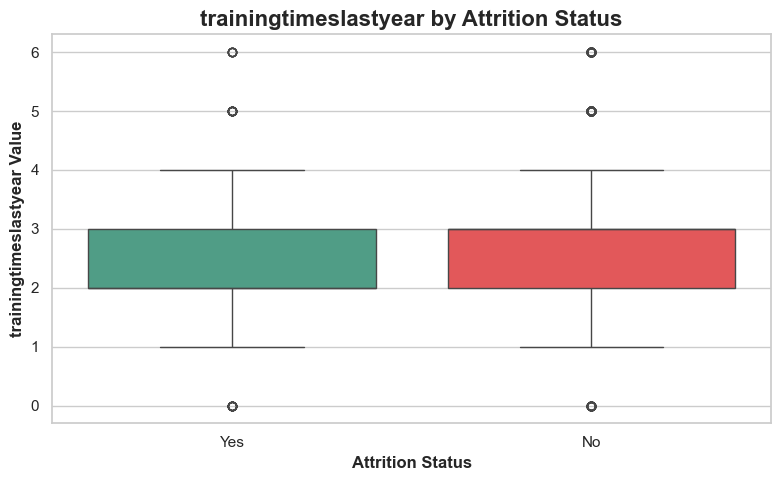


Pivot Summary for worklifebalance by Attrition:
                     mean          median             min             max
          worklifebalance worklifebalance worklifebalance worklifebalance
attrition                                                                
No               2.781022             3.0               1               4
Yes              2.658228             3.0               1               4


<Figure size 640x480 with 0 Axes>

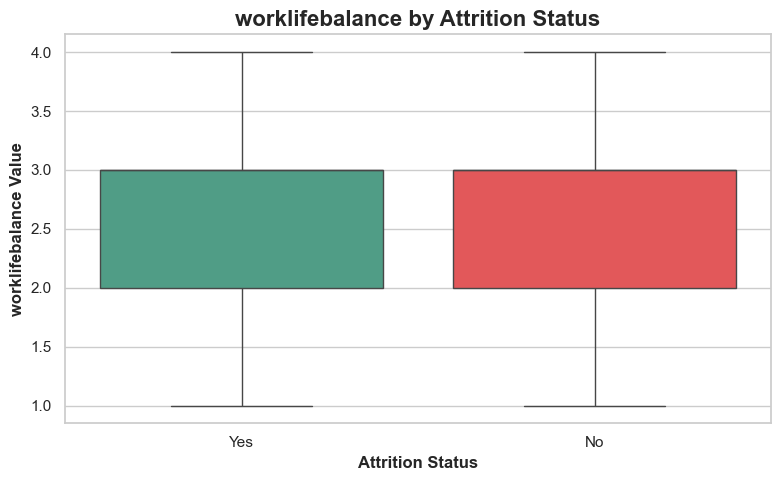


Pivot Summary for yearsatcompany by Attrition:
                    mean         median            min            max
          yearsatcompany yearsatcompany yearsatcompany yearsatcompany
attrition                                                            
No              7.369019            6.0              0             37
Yes             5.130802            3.0              0             40


<Figure size 640x480 with 0 Axes>

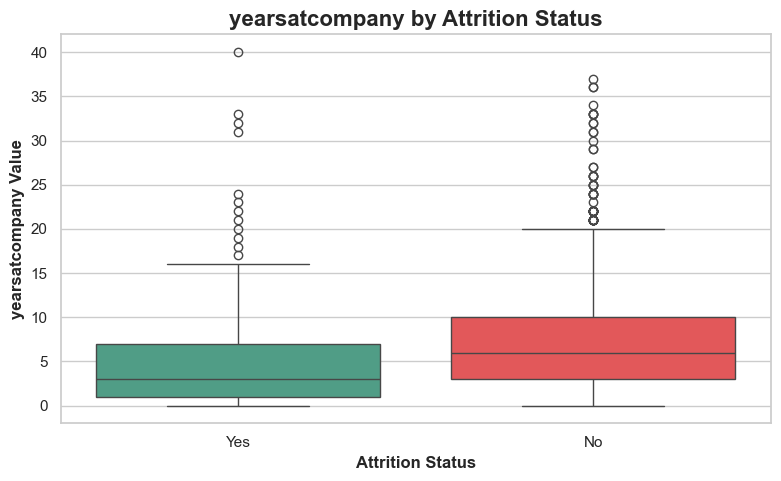


Pivot Summary for yearsincurrentrole by Attrition:
                        mean             median                min  \
          yearsincurrentrole yearsincurrentrole yearsincurrentrole   
attrition                                                            
No                  4.484185                3.0                  0   
Yes                 2.902954                2.0                  0   

                         max  
          yearsincurrentrole  
attrition                     
No                        18  
Yes                       15  


<Figure size 640x480 with 0 Axes>

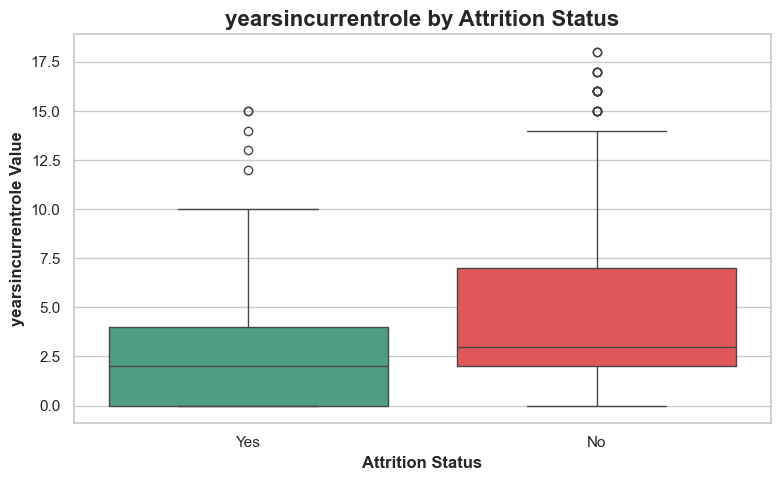


Pivot Summary for yearssincelastpromotion by Attrition:
                             mean                  median  \
          yearssincelastpromotion yearssincelastpromotion   
attrition                                                   
No                       2.234388                     1.0   
Yes                      1.945148                     1.0   

                              min                     max  
          yearssincelastpromotion yearssincelastpromotion  
attrition                                                  
No                              0                      15  
Yes                             0                      15  


<Figure size 640x480 with 0 Axes>

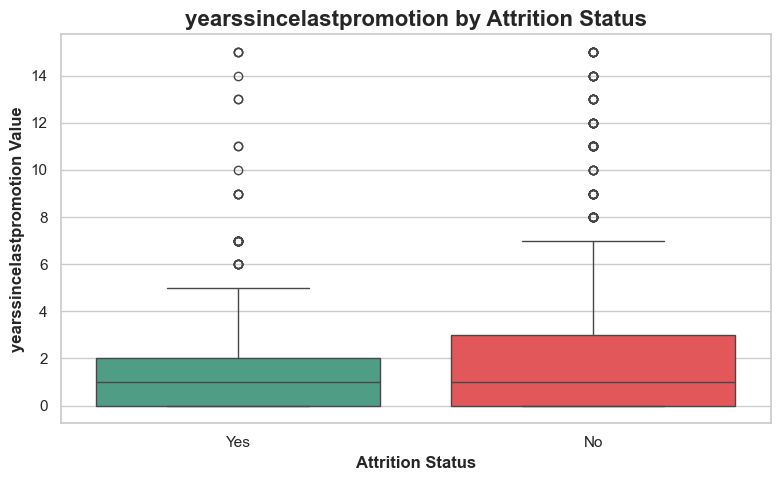


Pivot Summary for yearswithcurrmanager by Attrition:
                          mean               median                  min  \
          yearswithcurrmanager yearswithcurrmanager yearswithcurrmanager   
attrition                                                                  
No                    4.367397                  3.0                    0   
Yes                   2.852321                  2.0                    0   

                           max  
          yearswithcurrmanager  
attrition                       
No                          17  
Yes                         14  


<Figure size 640x480 with 0 Axes>

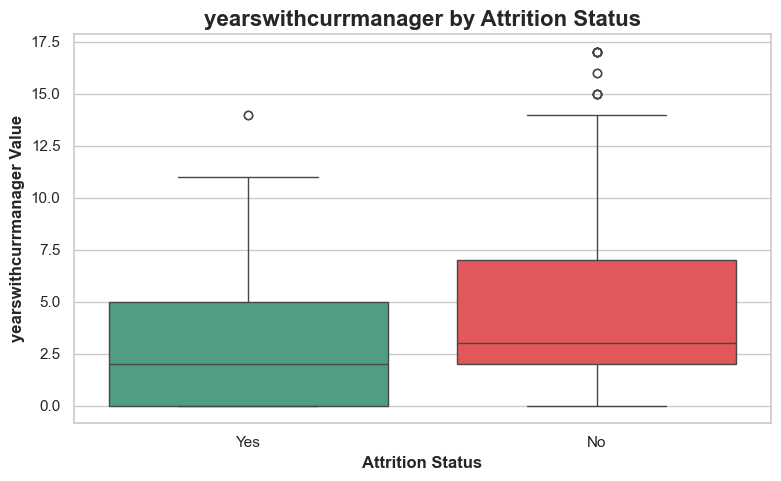

<Figure size 640x480 with 0 Axes>

In [39]:

# ---- Numeric Features vs Attrition ----
for col in df.select_dtypes('number').columns:
    if col == 'attrition': continue
    print(f"\nPivot Summary for {col} by Attrition:")
    print(df.pivot_table(index='attrition', values=col, aggfunc=['mean', 'median', 'min', 'max']))
    plt.figure(figsize=(8,5))
    sns.boxplot(x='attrition', y=col, data=df, palette=['#43aa8b', '#f94144'])
    plt.title(f"{col} by Attrition Status", fontweight='bold')
    plt.xlabel("Attrition Status")
    plt.ylabel(f"{col} Value")
    plt.tight_layout()
    savefig_and_show(f"{col}_boxplot")


---


# **7. CORRELATION ANALYSIS & HIGH CORRELATION LIST**


In [40]:
corr = df.select_dtypes('number').corr()
print("\nCorrelation Matrix (head):")
print(corr.head())



Correlation Matrix (head):
                              age  dailyrate  distancefromhome  education  \
age                      1.000000   0.010661         -0.001686   0.208034   
dailyrate                0.010661   1.000000         -0.004985  -0.016806   
distancefromhome        -0.001686  -0.004985          1.000000   0.021042   
education                0.208034  -0.016806          0.021042   1.000000   
environmentsatisfaction  0.010146   0.018355         -0.016075  -0.027128   

                         environmentsatisfaction  hourlyrate  jobinvolvement  \
age                                     0.010146    0.024287        0.029820   
dailyrate                               0.018355    0.023381        0.046135   
distancefromhome                       -0.016075    0.031131        0.008783   
education                              -0.027128    0.016775        0.042438   
environmentsatisfaction                 1.000000   -0.049857       -0.008278   

                         job

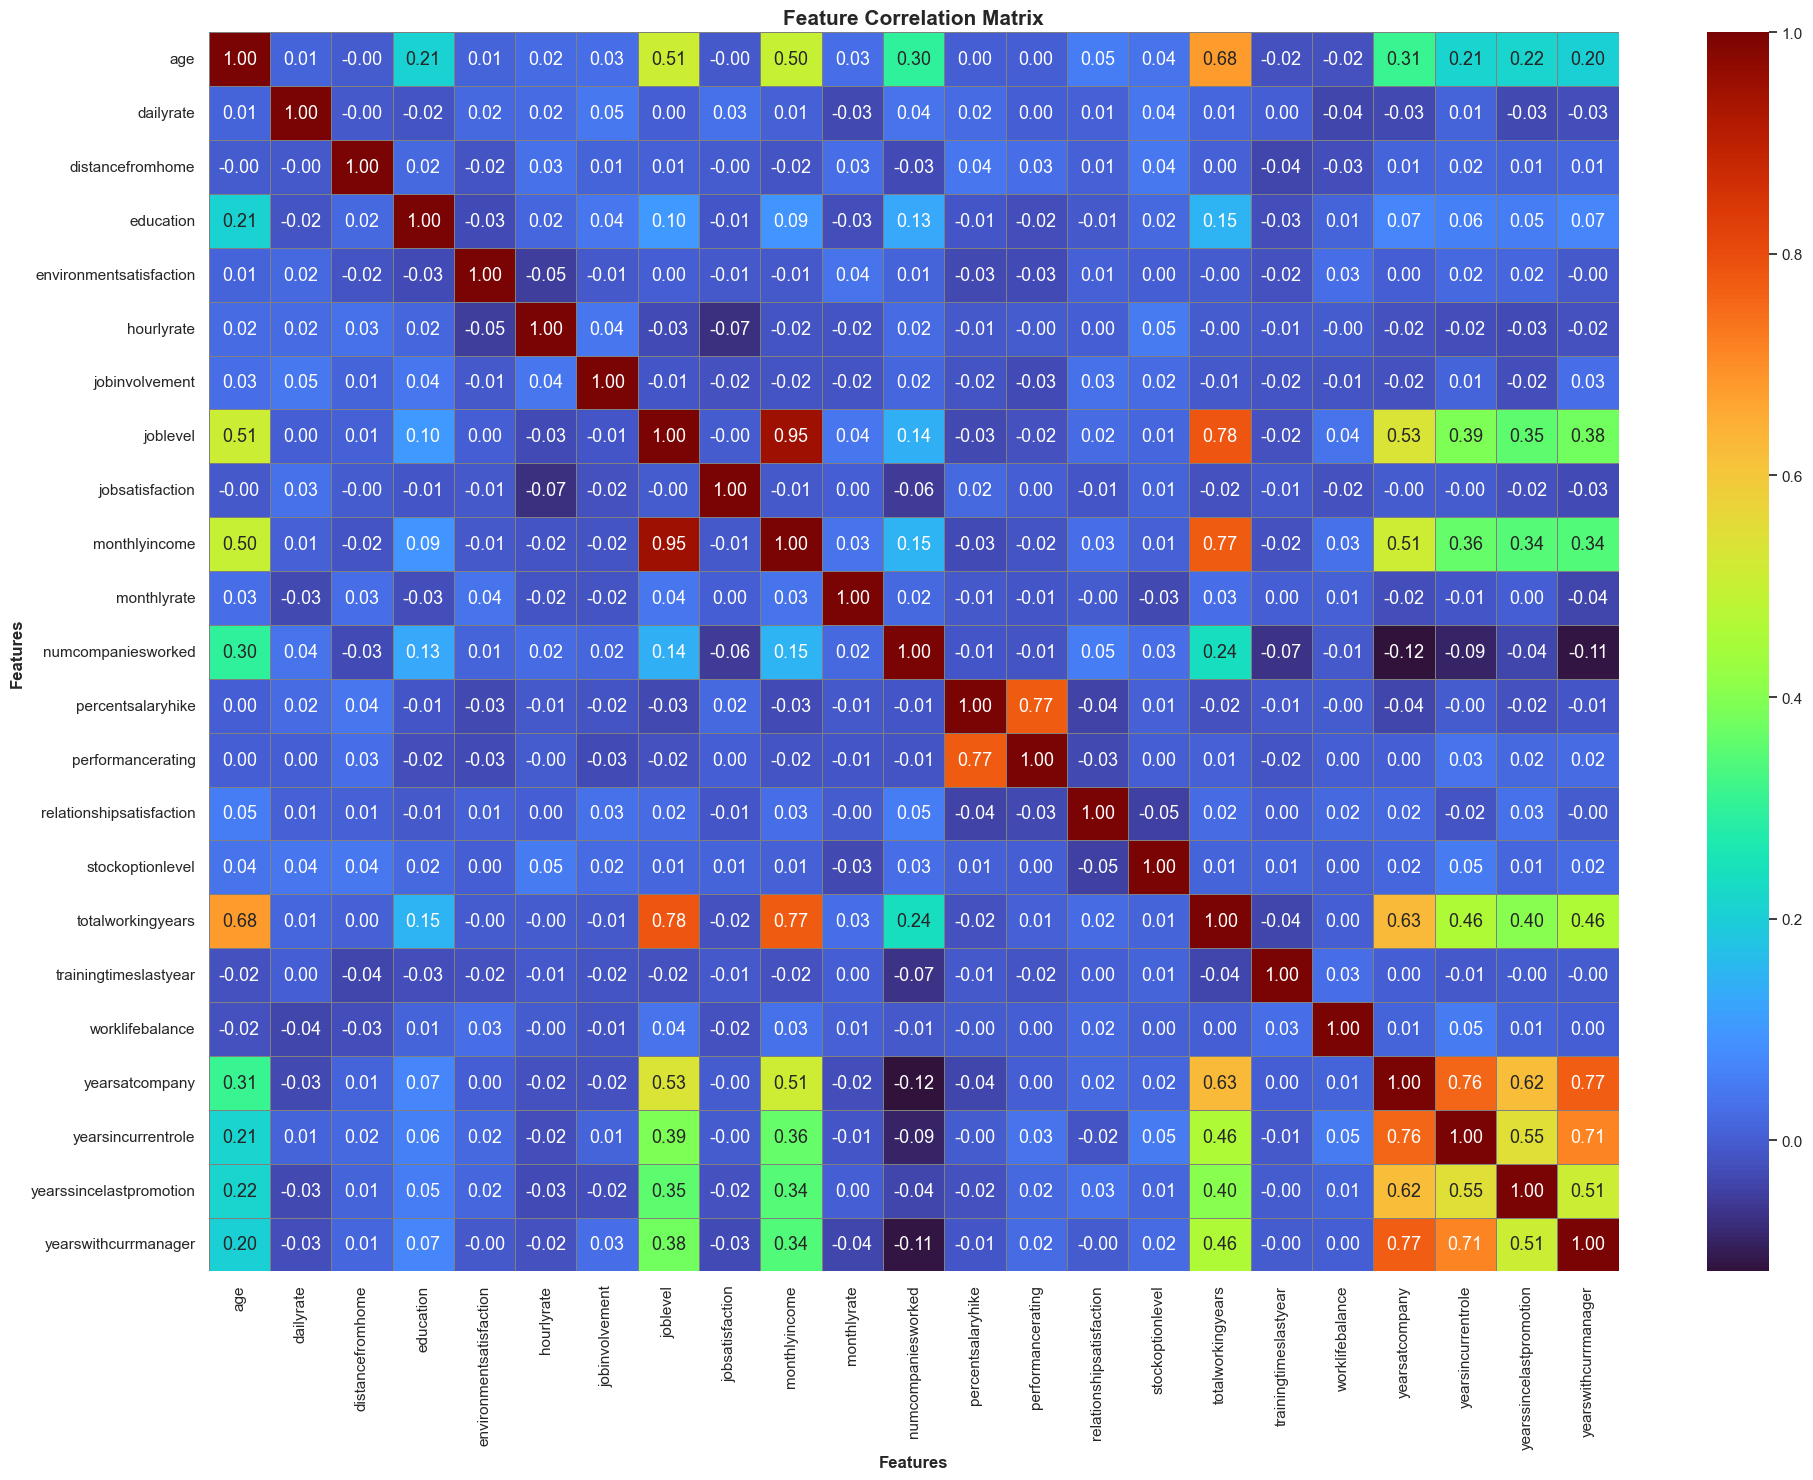

<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='turbo', linewidths=0.7, linecolor='grey')
plt.title("Feature Correlation Matrix", fontsize=15, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
savefig_and_show('correlation_matrix')


In [42]:

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = corr_pairs.stack().reset_index()
high_corr.columns = ["Feature1", "Feature2", "Correlation"]
high_corr = high_corr.loc[high_corr['Correlation'].abs() >= 0.7]
print("\n**Highly Correlated Features (|corr| >= 0.7):**")
print(high_corr if not high_corr.empty else "No highly correlated pairs found.")



**Highly Correlated Features (|corr| >= 0.7):**
               Feature1              Feature2  Correlation
134            joblevel         monthlyincome     0.950300
141            joblevel     totalworkingyears     0.782208
168       monthlyincome     totalworkingyears     0.772893
198   percentsalaryhike     performancerating     0.773550
247      yearsatcompany    yearsincurrentrole     0.758754
249      yearsatcompany  yearswithcurrmanager     0.769212
251  yearsincurrentrole  yearswithcurrmanager     0.714365


---


# **8. OUTLIER REMOVAL & FINAL DATA EXPORT**


In [43]:
df_clean = df.copy()


In [44]:
for col in df.select_dtypes('number').columns:
    if col == 'attrition': continue
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_clean = df_clean[(df_clean[col] >= lo) & (df_clean[col] <= hi)]
print(f"\nShape after outlier removal: {df_clean.shape}")



Shape after outlier removal: (699, 31)


In [45]:

df_clean.to_csv('analyzed_attrition_data.csv', index=False)
print("\nCleaned file saved as analyzed_attrition_data.csv")



Cleaned file saved as analyzed_attrition_data.csv


---

# **Insights Summary**



### 1. Attrition Level
- Overall attrition rate is **16.12%**, showing a moderately stable workforce.

### 2. Age & Experience Impact
- Employees who left are **younger** (30 vs 35 median age).
- They also have **lower total working experience** (6 vs 9 years).
- They spend **less time at the company** (3 vs 5 years).

### 3. Salary, Job Level & Financial Factors
- Employees who left earn **significantly less** (₹2857 vs ₹4487 monthly income).
- Highest exits are from **Job Level 1**.
- Attrition employees typically have **stock option level 0** (vs 1 for retained).

### 4. Work Environment & Satisfaction
- Lower environment satisfaction among attrition group (2 vs 3).
- No major difference in job satisfaction, involvement, or performance rating.

### 5. Work-life & Overtime Patterns
- Higher attrition among employees with **No Overtime**, hinting disengagement or low workload.
- Work-life balance median is similar for both groups.

### 6. Distance & Travel
- Employees who left live **farther** from office (9 km vs 7 km).
- Highest attrition in **Travel_Rarely** category (0.65 proportion).

### 7. Department & Job Role Risk
- Highest attrition in **Research & Development**.
- By job role, **Laboratory Technicians** show the highest exit rate.

### 8. Demographic Risk Segments
- Higher attrition among **males**.
- **Single** employees leave more than married employees.

### 9. Most Powerful Predictors of Attrition
Top 5 features correlated with attrition:
1. **Years at company** (0.225)
2. **Total working years** (0.218)
3. **Stock option level** (0.208)
4. **Years with current manager** (0.205)
5. **Years in current role** (0.197)
